<table style="width:100%;">
  <tr>
    <td style="text-align: left; vertical-align: middle;">
      <h2>Ciência de Dados</h2>
      <p>
        Prof. Túlio Ribeiro<br>
        <br>
        Núcleo de Ciência de Dados e Inteligência Artificial (NCDIA)<br>
        <br>
        Universidade de Fortaleza
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle;">
      <img src="https://www.unifor.br/o/unifor-theme/images/unifor-logo-horizontal.svg" width="200px">
    </td>
  </tr>
</table>

# Árvores de Decisão

## Setup e Importações

In [ ]:
# ==========================================
# CONFIGURAÇÕES INICIAIS E IMPORTAÇÕES
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sklearn.datasets import load_iris, make_moons
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from matplotlib.colors import ListedColormap

# Configurações visuais padrão do Matplotlib
import matplotlib as mpl
mpl.rc('axes', labelsize=12)
mpl.rc('xtick', labelsize=10)
mpl.rc('ytick', labelsize=10)
np.random.seed(42)

## 1. Classificação e Estrutura da Árvore

O algoritmo CART constrói a árvore fazendo divisões ortogonais (perpendiculares aos eixos) buscando maximizar a pureza dos nós. A métrica padrão para avaliar essa pureza é o **Coeficiente de Gini** ($Gini = 0$ significa que o nó é perfeitamente puro).

**Explore os parâmetros abaixo:**
* **Dataset:** Alterne entre os dados reais do Iris e dados sintéticos não-lineares (Moons).
* **max_depth (Profundidade Máxima):** Controla quantos níveis de perguntas a árvore pode fazer. Valores altos levam ao *overfitting*.
* **min_samples_leaf:** Exige que cada folha final tenha um número mínimo de amostras. É a principal técnica de "poda" (regularização) para evitar que a árvore crie regras específicas para pontos isolados (ruído).

In [ ]:
# ==========================================
# PREPARAÇÃO DOS DADOS
# ==========================================
# Dataset 1: Iris (Apenas comprimento e largura da pétala)
iris = load_iris()
X_iris = iris.data[:, 2:]
y_iris = iris.target

# Dataset 2: Moons (Padrão não-linear)
X_moons, y_moons = make_moons(n_samples=100, noise=0.25, random_state=53)

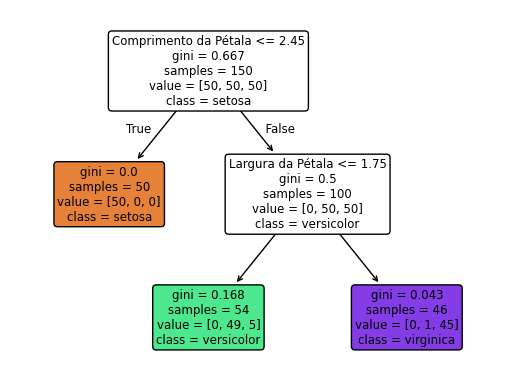

In [ ]:
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

plot_tree(tree_clf, feature_names=['Comprimento da Pétala', 'Largura da Pétala'], class_names=iris.target_names, filled=True, rounded=True)
plt.show()

In [ ]:
tree_clf.feature_importances_

array([0.56199095, 0.43800905])

In [ ]:
# ==========================================
# SIMULADOR INTERATIVO
# ==========================================
def interactive_classification(dataset, max_depth, min_samples_leaf):
    # Seleção do conjunto de dados
    if dataset == 'Iris (Botânica)':
        X, y = X_iris, y_iris
        feature_names = ['Comprimento da Pétala', 'Largura da Pétala']
        class_names = iris.target_names
        custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    else:
        X, y = X_moons, y_moons
        feature_names = ['X1', 'X2']
        class_names = ['Classe 0', 'Classe 1']
        custom_cmap = ListedColormap(['#fafab0','#9898ff'])

    # Treinamento do Modelo
    # Se max_depth for 0, deixamos a árvore crescer livremente (None)
    depth = None if max_depth == 0 else max_depth
    tree_clf = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=min_samples_leaf, random_state=42)
    tree_clf.fit(X, y)

    # Configuração da Figura (Lado a Lado)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8), gridspec_kw={'width_ratios': [1.2, 1]})

    # ----------------------------------------------------
    # PLOT 1: Fronteira de Decisão (Geometria)
    # ----------------------------------------------------
    x1s = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
    x2s = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = tree_clf.predict(X_new).reshape(x1.shape)

    ax1.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)

    # Plotagem dos pontos
    if dataset == 'Iris (Botânica)':
        ax1.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Setosa", markeredgecolor='k')
        ax1.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Versicolor", markeredgecolor='k')
        ax1.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Virginica", markeredgecolor='k')
    else:
        ax1.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Classe 0", markeredgecolor='k')
        ax1.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Classe 1", markeredgecolor='k')

    ax1.set_xlabel(feature_names[0], fontsize=12)
    ax1.set_ylabel(feature_names[1], fontsize=12)
    ax1.set_title("Fronteira de Decisão Ortogonal", fontsize=14)
    ax1.legend()

    # ----------------------------------------------------
    # PLOT 2: Estrutura da Árvore (Grafo Matemático)
    # ----------------------------------------------------
    plot_tree(tree_clf, feature_names=feature_names, class_names=class_names,
              filled=True, rounded=True, ax=ax2, fontsize=9)
    ax2.set_title("Grafo da Árvore (Cálculo do Gini)", fontsize=14)

    plt.tight_layout()
    plt.show()

# Controles
widgets.interact(
    interactive_classification,
    dataset=widgets.Dropdown(options=['Iris (Botânica)', 'Moons (Sintético)'], value='Iris (Botânica)', description='Dataset:'),
    max_depth=widgets.IntSlider(value=2, min=0, max=10, description='Max Depth (0=Livre):', style={'description_width': 'initial'}, continuous_update=False),
    min_samples_leaf=widgets.IntSlider(value=1, min=1, max=20, description='Min Samples Leaf:', style={'description_width': 'initial'}, continuous_update=False)
);

interactive(children=(Dropdown(description='Dataset:', options=('Iris (Botânica)', 'Moons (Sintético)'), value…

### 1.1 Sensibilidade aos Detalhes (Alta Variância)

As Árvores de Decisão são altamente sensíveis a pequenas variações nos dados de treinamento. Para demonstrar isso, vamos treinar o modelo no dataset original do Iris e, em seguida, treinar um novo modelo removendo **apenas uma única amostra**: a flor da classe *Versicolor* que possui a maior largura de pétala.

Observe como a remoção de um único ponto altera drasticamente a regra de corte do modelo (a fronteira de decisão muda completamente de posição).

In [ ]:
# ==========================================
# SENSIBILIDADE A PEQUENAS VARIAÇÕES (REMOÇÃO DE 1 PONTO)
# ==========================================
from sklearn.inspection import DecisionBoundaryDisplay

# 1. Recuperando os dados originais do Iris
X_orig = iris.data[:, 2:]
y_orig = iris.target

# 2. Treinando o modelo original
tree_clf_orig = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_orig.fit(X_orig, y_orig)

# 3. Filtrando os dados: Removendo a Iris-Versicolor (y==1) com maior largura de pétala (X[:,1] == 1.8)
not_widest_versicolor = (X_orig[:, 1] != 1.8) | (y_orig == 2)
X_tweaked = X_orig[not_widest_versicolor]
y_tweaked = y_orig[not_widest_versicolor]

# 4. Treinando o novo modelo com a amostra removida
tree_clf_tweaked = DecisionTreeClassifier(max_depth=2, random_state=40)
tree_clf_tweaked.fit(X_tweaked, y_tweaked)

DecisionTreeClassifier(max_depth=2, random_state=40)

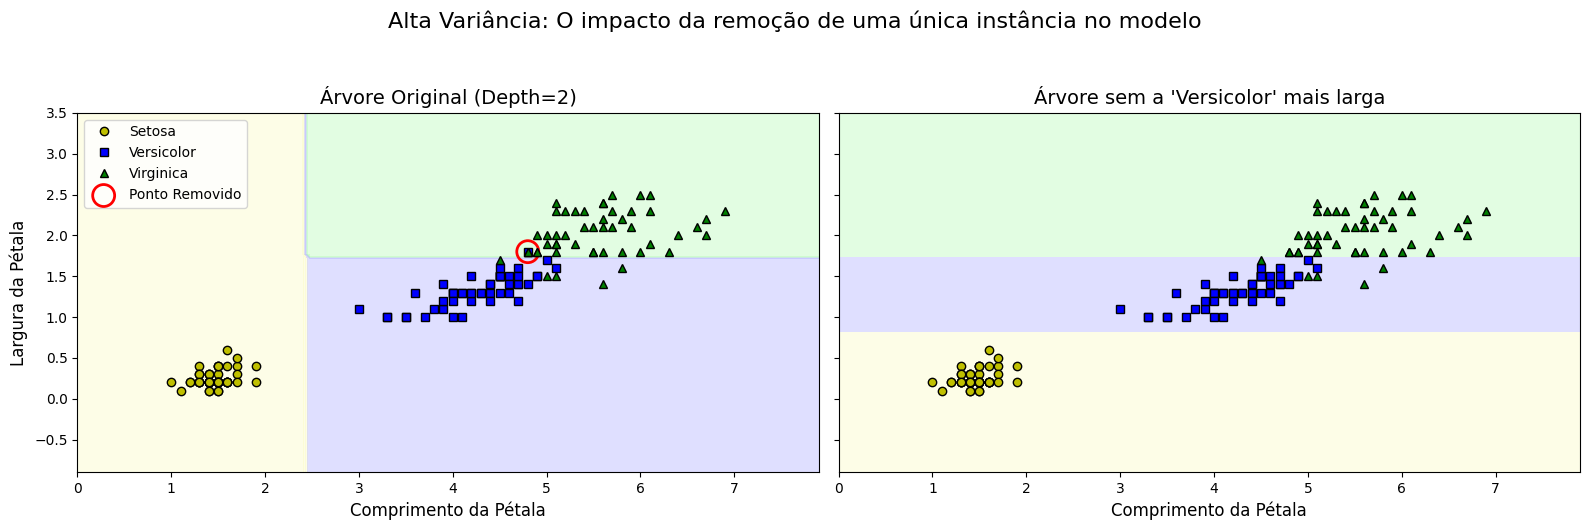

In [ ]:
# ==========================================
# PLOTAGEM COMPARATIVA
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])

# --- PLOT 1: Original ---
DecisionBoundaryDisplay.from_estimator(tree_clf_orig, X_orig, cmap=custom_cmap, alpha=0.3, ax=ax1, response_method="predict")
ax1.plot(X_orig[:, 0][y_orig==0], X_orig[:, 1][y_orig==0], "yo", markeredgecolor='k', label="Setosa")
ax1.plot(X_orig[:, 0][y_orig==1], X_orig[:, 1][y_orig==1], "bs", markeredgecolor='k', label="Versicolor")
ax1.plot(X_orig[:, 0][y_orig==2], X_orig[:, 1][y_orig==2], "g^", markeredgecolor='k', label="Virginica")

# Destacando com um círculo vermelho o ponto que será removido
ponto_removido = X_orig[(X_orig[:, 1] == 1.8) & (y_orig == 1)]
ax1.scatter(ponto_removido[:, 0], ponto_removido[:, 1], s=250, facecolors='none', edgecolors='r', linewidths=2, label="Ponto Removido")

ax1.set_title("Árvore Original (Depth=2)", fontsize=14)
ax1.set_xlabel("Comprimento da Pétala", fontsize=12)
ax1.set_ylabel("Largura da Pétala", fontsize=12)
ax1.legend(loc="upper left")

# --- PLOT 2: Modificado (Sem o Ponto) ---
DecisionBoundaryDisplay.from_estimator(tree_clf_tweaked, X_tweaked, cmap=custom_cmap, alpha=0.3, ax=ax2, response_method="predict")
ax2.plot(X_tweaked[:, 0][y_tweaked==0], X_tweaked[:, 1][y_tweaked==0], "yo", markeredgecolor='k')
ax2.plot(X_tweaked[:, 0][y_tweaked==1], X_tweaked[:, 1][y_tweaked==1], "bs", markeredgecolor='k')
ax2.plot(X_tweaked[:, 0][y_tweaked==2], X_tweaked[:, 1][y_tweaked==2], "g^", markeredgecolor='k')

ax2.set_title("Árvore sem a 'Versicolor' mais larga", fontsize=14)
ax2.set_xlabel("Comprimento da Pétala", fontsize=12)

plt.suptitle("Alta Variância: O impacto da remoção de uma única instância no modelo", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## 2. A Instabilidade Geométrica (Limitação)

Uma das maiores fraquezas das Árvores de Decisão é sua preferência por divisões ortogonais (sempre retas verticais ou horizontais).

Quando os dados estão dispostos de forma **diagonal**, a árvore precisa criar uma fronteira em formato de "escada" ou "degraus" para separá-los. Isso torna o modelo altamente sensível à rotação dos dados de treinamento.

*No simulador abaixo, gire os dados e observe como a árvore precisa aumentar sua complexidade drásticamente para separar um conjunto que, a rigor, poderia ser dividido por uma única linha reta inclinada.*

In [ ]:
# ==========================================
# PREPARAÇÃO DOS DADOS (Quadrado Linear)
# ==========================================
np.random.seed(6)
Xs = np.random.rand(100, 2) - 0.5
ys = (Xs[:, 0] > 0).astype(np.float32) * 2

In [ ]:
# ==========================================
# SIMULADOR DE ROTAÇÃO
# ==========================================
def plot_rotated_tree(angle_degrees):
    # Conversão para radianos e aplicação da matriz de rotação
    angle = np.pi / 180 * angle_degrees
    rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],
                                [np.sin(angle), np.cos(angle)]])
    Xsr = Xs.dot(rotation_matrix)

    # Treinamento
    tree_clf_sr = DecisionTreeClassifier(random_state=42)
    tree_clf_sr.fit(Xsr, ys)

    # Plotagem
    fig, ax = plt.subplots(figsize=(8, 6))

    x1s = np.linspace(-0.8, 0.8, 100)
    x2s = np.linspace(-0.8, 0.8, 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = tree_clf_sr.predict(X_new).reshape(x1.shape)

    custom_cmap = ListedColormap(['#fafab0','#9898ff'])
    ax.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)

    ax.plot(Xsr[:, 0][ys==0], Xsr[:, 1][ys==0], "yo", markeredgecolor='k')
    ax.plot(Xsr[:, 0][ys==2], Xsr[:, 1][ys==2], "bs", markeredgecolor='k')

    ax.set_title(f"Rotação de {angle_degrees} graus | Profundidade gerada: {tree_clf_sr.get_depth()}", fontsize=14)
    ax.set_xlim(-0.7, 0.7)
    ax.set_ylim(-0.7, 0.7)
    plt.show()

# Controles
widgets.interact(
    plot_rotated_tree,
    angle_degrees=widgets.IntSlider(value=0, min=0, max=90, step=5, description='Ângulo (°):', continuous_update=False)
);

interactive(children=(IntSlider(value=0, continuous_update=False, description='Ângulo (°):', max=90, step=5), …

## 3. Regressão

Na regressão, em vez de prever uma classe, cada nó folha calcula a **média** (valor alvo) das instâncias que caíram naquela região. O algoritmo busca divisões que minimizem o **Erro Quadrático Médio (MSE)** em vez da impureza de Gini.

Isso faz com que a predição da árvore não seja uma linha contínua, mas sim uma função "em degraus" (*step function*).

In [ ]:
# ==========================================
# PREPARAÇÃO DOS DADOS DE REGRESSÃO
# ==========================================
# Curva quadrática com ruído
np.random.seed(42)
m = 200
X_reg = np.random.rand(m, 1)
y_reg = 4 * (X_reg - 0.5) ** 2
y_reg = y_reg + np.random.randn(m, 1) / 10

In [ ]:
# ==========================================
# SIMULADOR DE REGRESSÃO
# ==========================================
def interactive_regression(max_depth, min_samples_leaf):
    # Treinamento (Se depth=0, cresce livremente)
    depth = None if max_depth == 0 else max_depth
    tree_reg = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=min_samples_leaf, random_state=42)
    tree_reg.fit(X_reg, y_reg)

    # Configuração da Figura
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [1.2, 1]})

    # ----------------------------------------------------
    # PLOT 1: Regressão em Degraus
    # ----------------------------------------------------
    x_plot = np.linspace(0, 1, 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x_plot)

    ax1.plot(X_reg, y_reg, "b.", label="Dados Reais", alpha=0.5)
    ax1.plot(x_plot, y_pred, "r.-", linewidth=2, label="Predição (Média do Nó)")

    ax1.set_xlabel("$x_1$", fontsize=14)
    ax1.set_ylabel("$y$", fontsize=14, rotation=0, labelpad=15)
    ax1.set_ylim(-0.2, 1.2)
    ax1.set_title("Função de Predição em Degraus", fontsize=14)
    ax1.legend(loc="upper center")

    # ----------------------------------------------------
    # PLOT 2: Estrutura da Árvore (Cálculo do MSE)
    # ----------------------------------------------------
    plot_tree(tree_reg, feature_names=['x1'], filled=True, rounded=True, ax=ax2, fontsize=9, precision=3)
    ax2.set_title("Grafo da Árvore (Cálculo do MSE)", fontsize=14)

    plt.tight_layout()
    plt.show()

# Controles
widgets.interact(
    interactive_regression,
    max_depth=widgets.IntSlider(value=2, min=0, max=10, description='Max Depth (0=Livre):', style={'description_width': 'initial'}, continuous_update=False),
    min_samples_leaf=widgets.IntSlider(value=1, min=1, max=30, description='Min Samples Leaf:', style={'description_width': 'initial'}, continuous_update=False)
);

interactive(children=(IntSlider(value=2, continuous_update=False, description='Max Depth (0=Livre):', max=10, …

In [ ]:
tree_reg = DecisionTreeRegressor(max_depth=10, min_samples_leaf=1, random_state=42)
tree_reg.fit(X_reg, y_reg)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [ ]:
tree_reg.feature_importances_

array([1.])

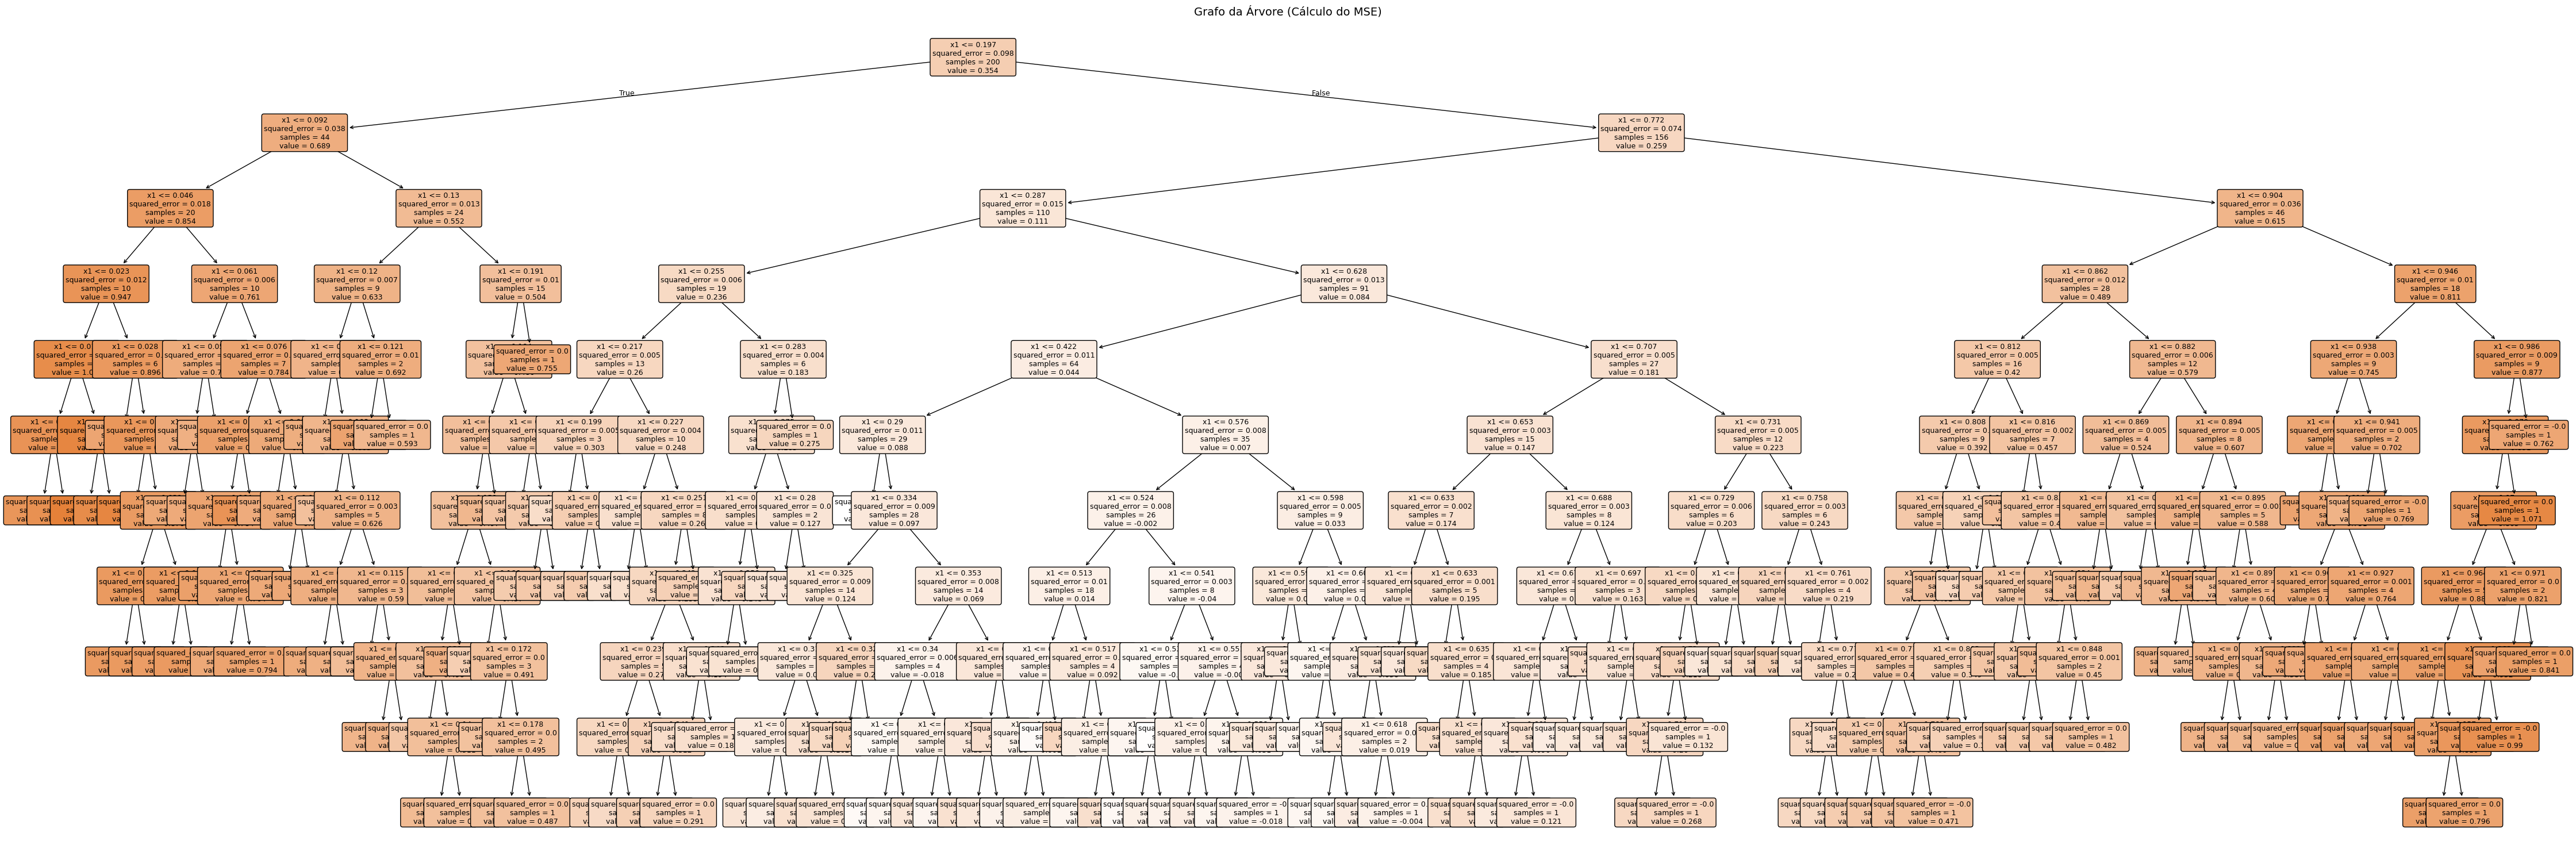

In [ ]:
# Configuração da Figura
fig, ax = plt.subplots(figsize=(45, 15))

# ----------------------------------------------------
# PLOT 2: Estrutura da Árvore (Cálculo do MSE)
# ----------------------------------------------------
plot_tree(tree_reg, feature_names=['x1'], filled=True, rounded=True, ax=ax, fontsize=9, precision=3)
ax.set_title("Grafo da Árvore (Cálculo do MSE)", fontsize=14)

plt.tight_layout()
plt.show()